In [16]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

from regularised_theta import * 

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


### Get the data

In [2]:
#Orthogonal Wavelet
W =   DefineWavelet('Db',m=3,device=device)

In [3]:
Data = load_turbulence_1d()
n1 = 1024  # desired subseries length
Data = split_periodize_reshape(Data, n1)
for j in range(5):
    Data =W.decompose(Data)[1]#(W.decompose(Data)[1])[1]#Data[:,:,::2]+Data[:,:,1::2]
x1 = normalize(Data[:1000]).to(device)
print(Data.shape)

torch.Size([10000, 1, 32])


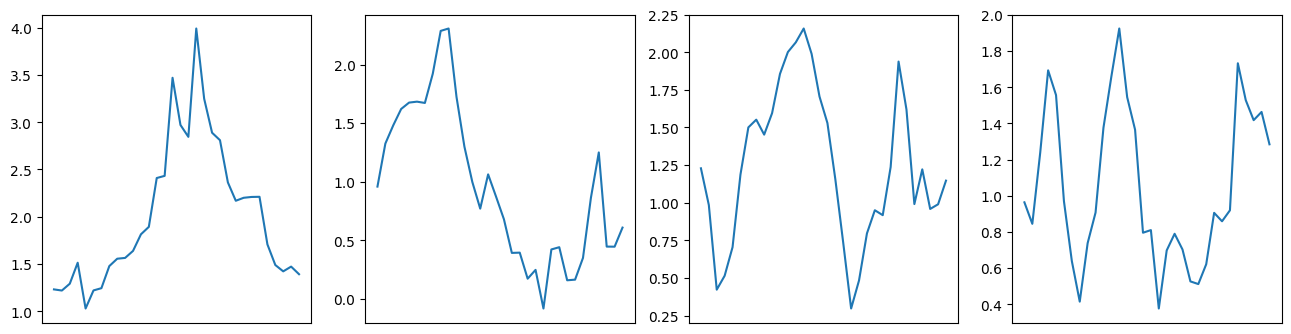

In [4]:
plot_time_series_row(x1, 4)

### Choose the model

In [5]:
n1, channels, M = x1.shape
print(f'(B, C, T) = ({n1}, {channels}, {M}).')

J = 5
Q = 3

# choose terms in the model
terms = ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
        'Scattering_Second_Order_Q1', 'Scattering_Fourth_Order_Real_Q1',
            'Scalar_psi_coshgt',
            'Scalar_morlet_coshgt',
            'Scalar_psi_maxent',
            'Scalar_morlet_maxent',
        ]#,'Scalar_phi_quantile_confine']
#Filters
filters,filters_Phi = return_Filters(M, J, 1, device=device,include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

(B, C, T) = (1000, 1, 32).


In [28]:
filters_Q.shape

torch.Size([1, 16, 32])

In [8]:
potentials =  get_1d_potentials(terms, J, filters, Q, filters_Q, filters_Phi,scalar_param=None, parallel=False)
print(potentials) 

{'Scalar_psi_coshgt': <potentials.potentials_1d.Scalar_coshgt object at 0x148c87d6de80>, 'Scalar_morlet_coshgt': <potentials.potentials_1d.Scalar_coshgt object at 0x148c87d6e810>, 'Scalar_psi_maxent': <potentials.potentials_1d.Scalar_maxent object at 0x148c87d6f410>, 'Scalar_morlet_maxent': <potentials.potentials_1d.Scalar_maxent object at 0x148c87d6e540>, 'Scattering_Second_Order': Scattering_Second_Order_1d(), 'Scattering_Fourth_Order_Real': Scattering_Fourth_Order_Real_1d(), 'Scattering_Second_Order_Q1': Scattering_Second_Order_1d(), 'Scattering_Fourth_Order_Real_Q1': Scattering_Fourth_Order_Real_1d()}


### Solve the SDE

In [9]:
# SDE parameters
interpolant = 'Cos'
nt          = 2000  # originally 50000
t           = 1-(1-torch.linspace(0, 1, nt + 1))**2
sigma       = 1

nb_workers      = x1.shape[0] # number of particles
nb_interpolants = x1.shape[0] # number of I_t (not necessarily the dataset size, since several noise paths could be considered per data sample)

batch_size = x1.shape[0]

regularization = 1e-2

Solver = SDE(x1, nb_workers, nb_interpolants, t, sigma, potentials, batch_size, device=device, regularization=regularization, interpolant=interpolant)

Signal detected as 1D: (B, C, T) = (1000, 1, 32).
The model has 311 potentials.


In [10]:
config = 'turbulence_synthesis_'+str(M)+'_J_'+str(J)+'_Q_'+str(Q)+'_sigma_'+str(sigma)

In [11]:
print(config)

turbulence_synthesis_32_J_5_Q_3_sigma_1


In [12]:
xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

[coshGT][ch 0] [tempered]  b=1.209  t=2.129  a=0.1658  x0=0.02219  (kappa=a*t=0.3529)
[coshGT][ch 1] [tempered]  b=1.431  t=2.070  a=0.2327  x0=0.02080  (kappa=a*t=0.4818)
[coshGT][ch 2] [tempered]  b=1.015  t=1.108  a=0.7887  x0=0.02832  (kappa=a*t=0.8742)
[coshGT][ch 3] [tempered]  b=1.018  t=0.620  a=1.6120  x0=0.03612  (kappa=a*t=1.0000)
[coshGT][ch 4] [tempered]  b=1.013  t=0.694  a=1.5077  x0=0.04372  (kappa=a*t=1.0456)
[coshGT][ch 5] [tempered]  b=2.187  t=1.425  a=0.6652  x0=0.05003  (kappa=a*t=0.9482)
[coshGT][ch 6] [tempered]  b=2.142  t=1.427  a=0.6602  x0=0.05690  (kappa=a*t=0.9420)
[coshGT][ch 7] [tempered]  b=1.004  t=0.771  a=1.4714  x0=0.07631  (kappa=a*t=1.1341)
[coshGT][ch 8] [tempered]  b=1.004  t=0.783  a=1.4279  x0=0.10403  (kappa=a*t=1.1178)
[coshGT][ch 9] [tempered]  b=1.019  t=0.807  a=1.3652  x0=0.10436  (kappa=a*t=1.1018)
[coshGT][ch 10] [tempered]  b=1.004  t=0.787  a=1.4380  x0=0.11953  (kappa=a*t=1.1320)
[coshGT][ch 11] [      GT]  b=6.347  t=3.478  a=0.000

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_1d.py:1378: RuntimeWarning: overflow encountered in exp
  p0 = p0_lo + (p0_hi - p0_lo) / (1.0 + np.exp(-u[k])); k += 1


[MaxEnt][ch 15] p0=0.200, s0=9510.9731, theta=(0.000,64667033.524,0.001)
[MaxEnt][ch 0] p0=0.652, s0=0.0719, theta=(0.322,1.443,0.792)
[MaxEnt][ch 1] p0=1.241, s0=0.0967, theta=(7.999,1.077,1.976)
[MaxEnt][ch 2] p0=0.401, s0=0.2621, theta=(0.113,3.768,0.971)
[MaxEnt][ch 3] p0=1.500, s0=0.5815, theta=(0.932,8.620,0.007)
[MaxEnt][ch 4] p0=0.207, s0=1.0353, theta=(0.001,13.977,0.008)
[MaxEnt][ch 5] p0=1.500, s0=9496.8414, theta=(0.000,64451166.336,0.001)


2000it [01:03, 31.36it/s]


## Regularize theta, Guth method

In [26]:
print(xt.shape) 
print(x0.shape) 
print(t.shape) 

torch.Size([1000, 1, 32])
torch.Size([1000, 1, 32])
torch.Size([2001])


In [29]:
theta_t.shape

torch.Size([2001, 311])

In [25]:
# --- reshape xt into list of levels ---
# xt is (nt, B, C, T)
X_levels = [xt[k] for k in range(xt.shape[0])]


s_levels = [(xt[k] - x1[k]) for k in range(xt.shape[0])] 

# dimension
dim = x1.shape[-2] * x1.shape[-1]

# 1) Reuse the potentials your sampler already fitted on x1.
potentials = Solver.potentials          # fit_reference already done

# 2) Pick a MODEST regularisation grid and gather the per-level quantities.
    # t        : (n_t,) increasing in (0, 1]      (subsample your fine grid)
    # X_levels : [walkers at t_k]   each (B, C, T)
    # s_levels : [(X_t - X_0)/t]    each (B, C, T)  -- same residual as b_t
    # M_levels : (n_t, r, r)        from your pointwise solve
    # b_levels : (n_t, r)           from your pointwise solve
    # dim      = x1.shape[-2] * x1.shape[-1]

# 3) Solve.
Theta_reg = regularise(potentials, t, X_levels, s_levels,
                      M_levels, b_levels, dim)
print("Regularised theta:", Theta_reg.shape)   # (n_t, r); theta_1 = [-1]

<class 'NameError'>: name 'M_levels' is not defined

In [17]:
save_results(xt, theta_t, dH_t_bound, t, root.parent, config)

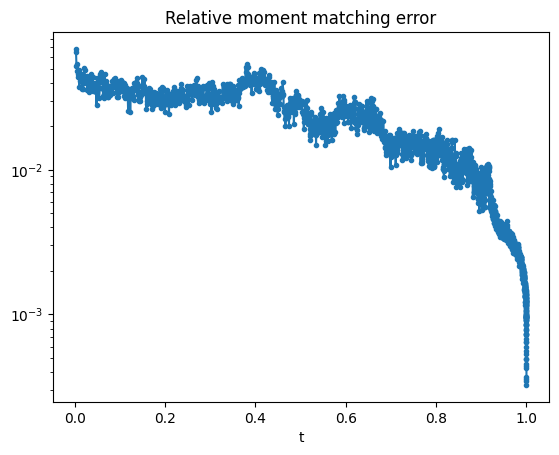

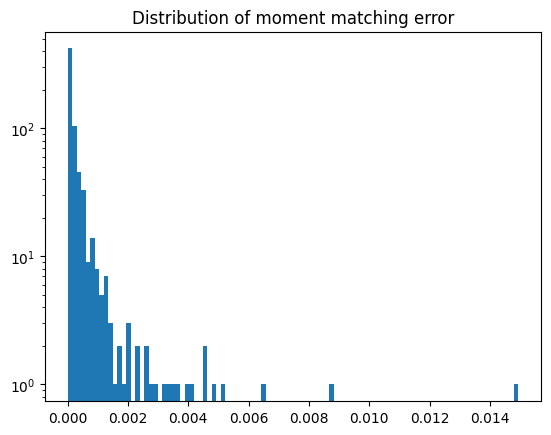

In [18]:
# Check (non negligible) moments matching
threshold = 1e-8 # threshold above which should be considered

plot_moment_matching(barphi_e, barphi_p, t, threshold)

In [20]:
xt, theta_t, dH_t_bound, t =load_results( root.parent, config)

## Analyze the result

Looking at the samples and moment matching along the dynamics:

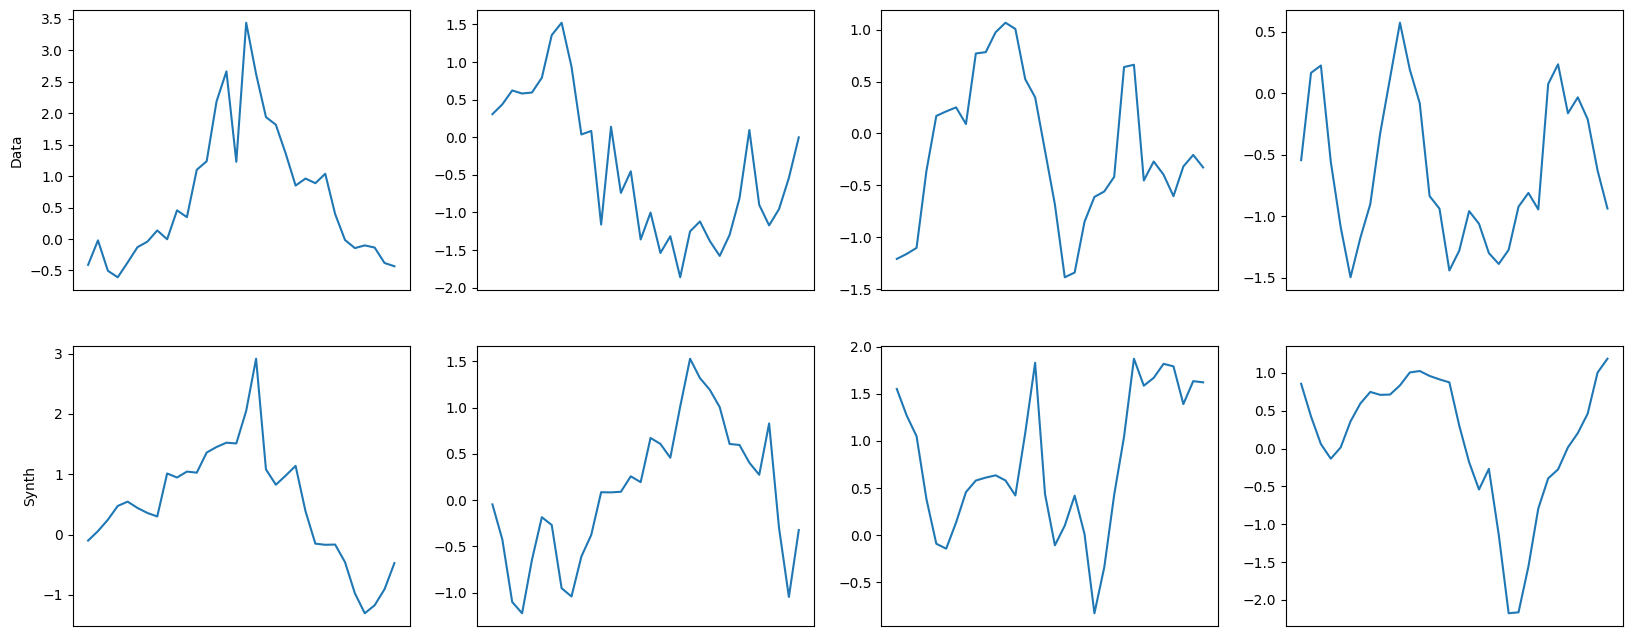

In [21]:
# Visual Check
Compare_time_series_row(x1,xt, 4)

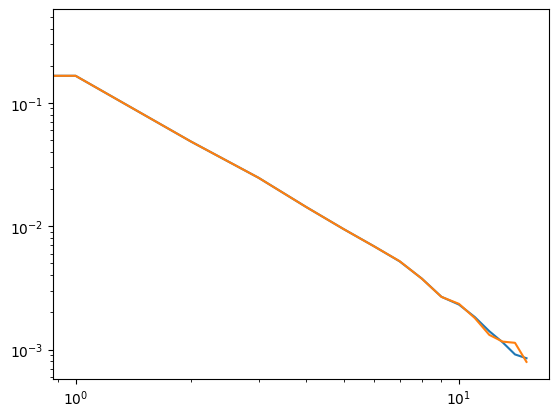

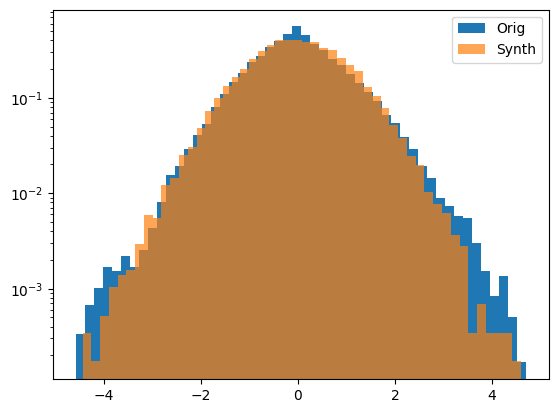

In [22]:
# Check Statistical Properties
spec_plot(x1,xt)

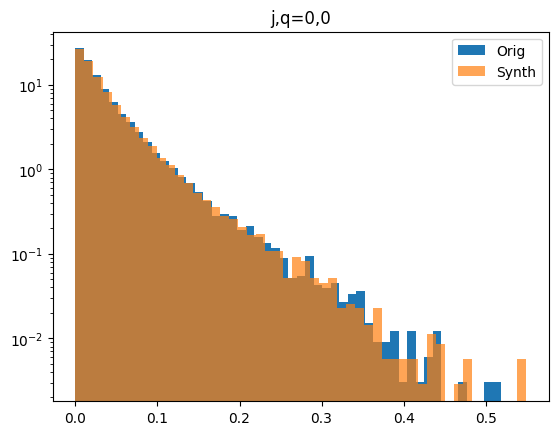

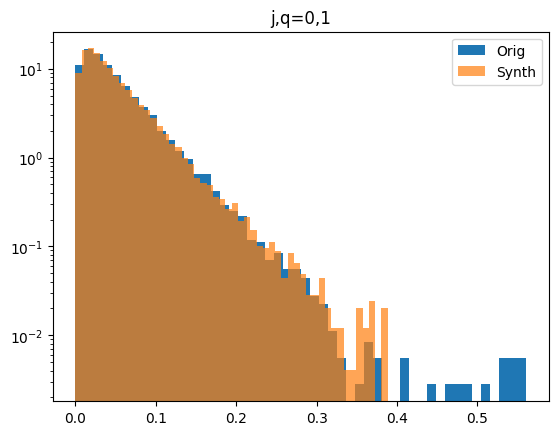

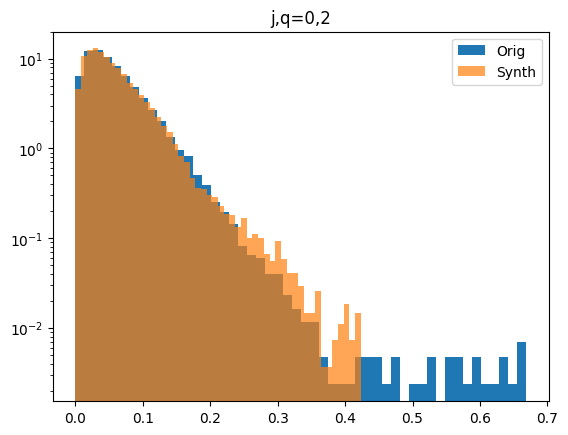

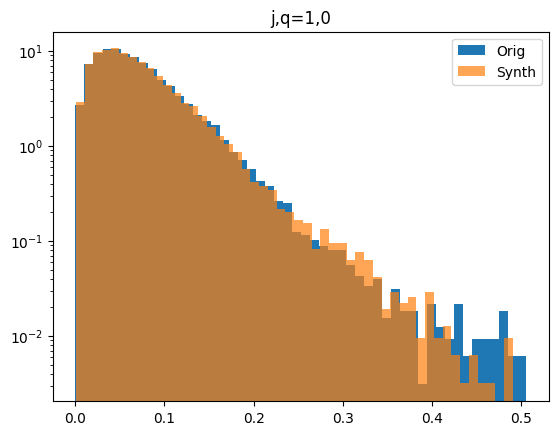

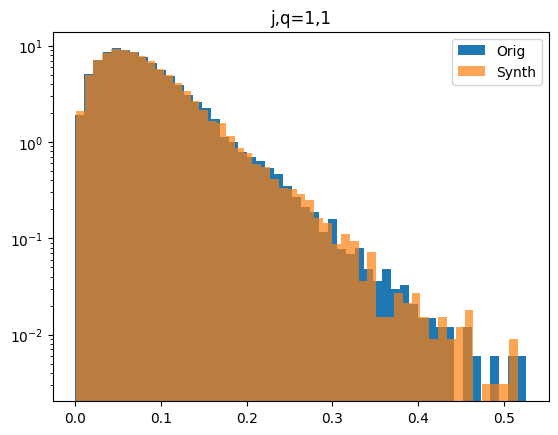

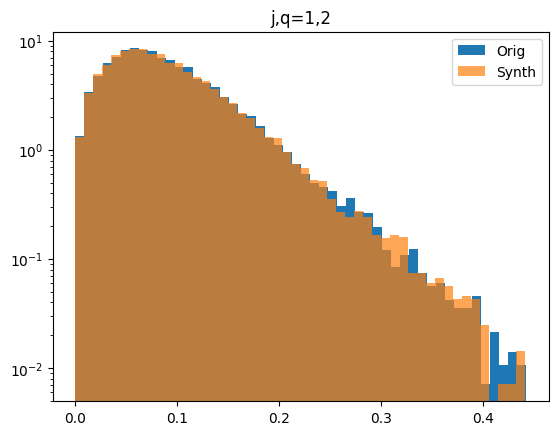

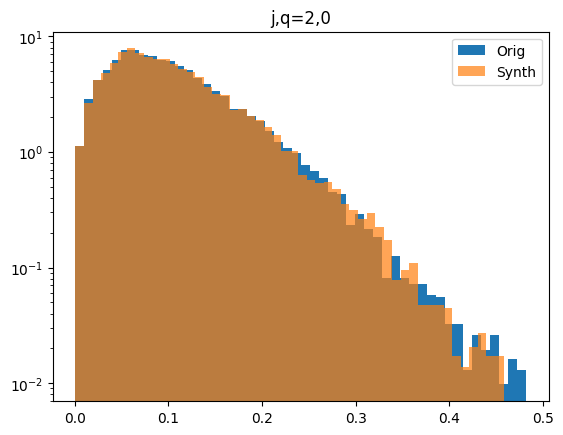

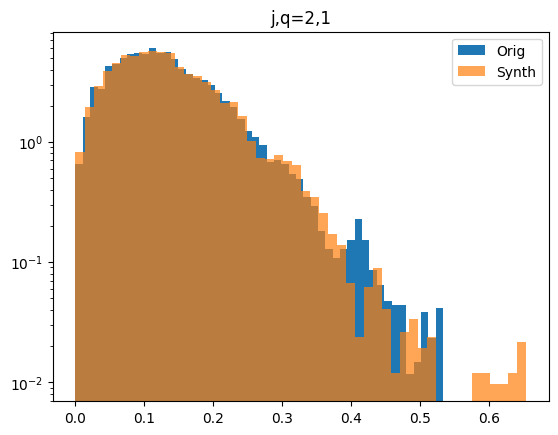

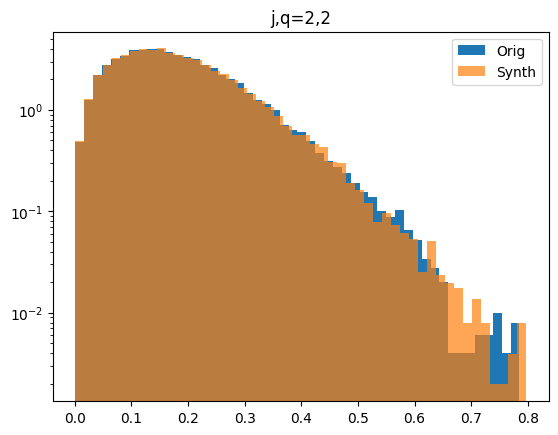

In [23]:
hist_plot(x1,xt)

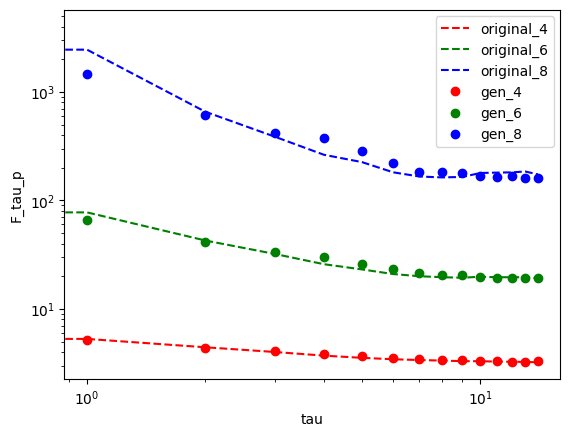

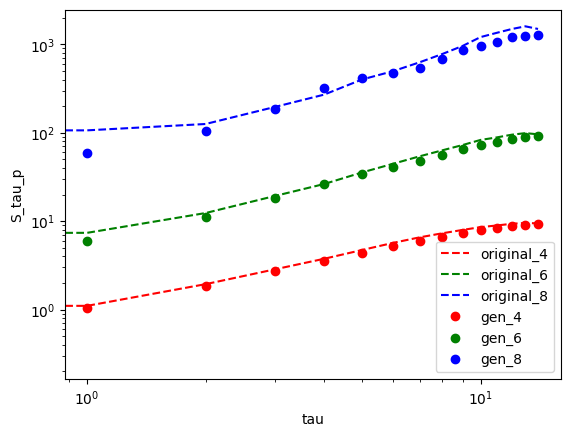

In [24]:
structure_plot(x1,xt)

(p,q)= (3, 1)


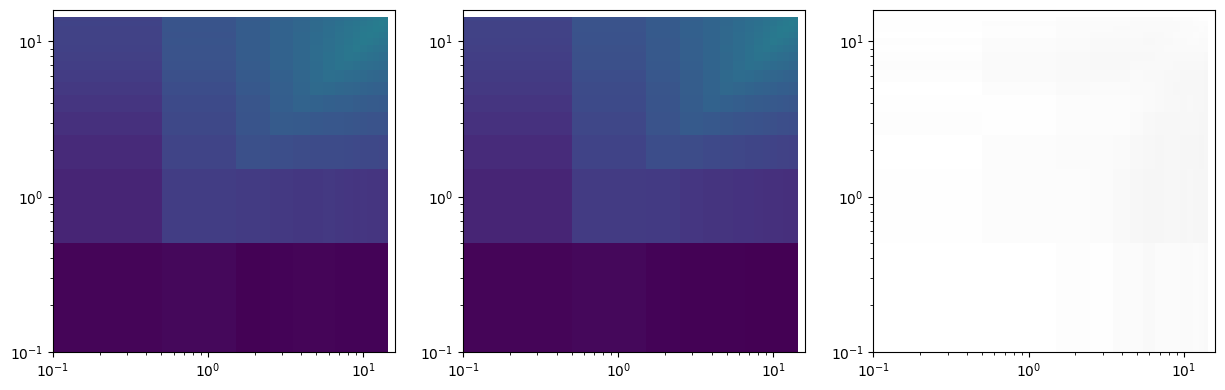

(p,q)= (3, 3)


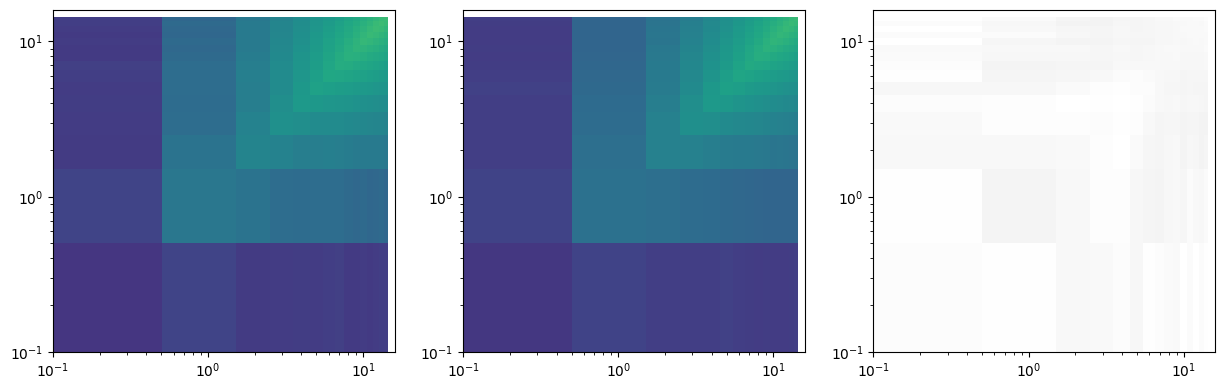

(p,q)= (4, 4)


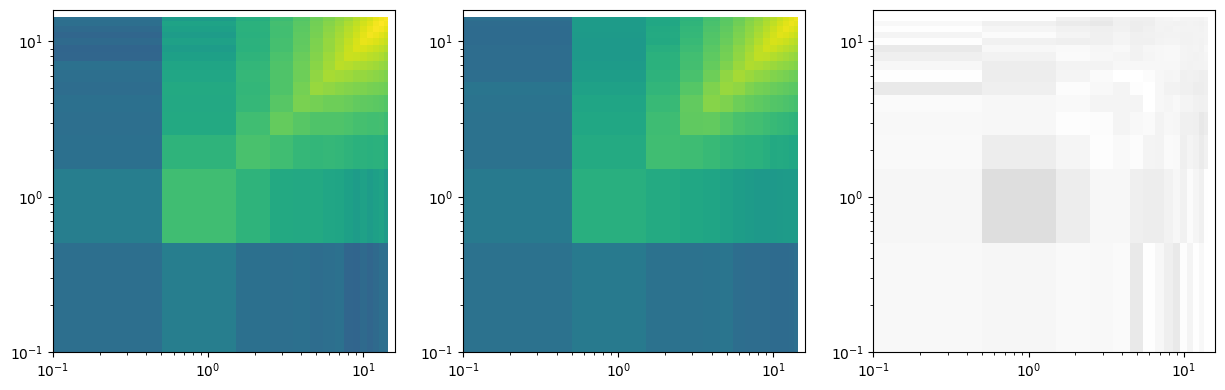

In [25]:
cross_plot(x1,xt,pq = [(3,1),(3,3),(4,4)])

Entropy bound evolution and comparison with the equivalent gaussian entropy (covariance directly estimated from the original data):

In [ ]:
d = x1.shape[-2]*x1.shape[-1]
H_p_0 = (np.log(2*np.pi)+1)*d/2

H_t_bound = dH_t_bound.cumsum(0).cpu()/nt + H_p_0
H_t_gaussian = compute_gaussian_entropy(x1, interpolant, t)

print('Entropy bound:', H_t_bound[-1], '.')
print('Gaussian estimation', H_t_gaussian[-1], '.')

plot_entropy_bound_evolution(dH_t_bound, H_t_bound, H_t_gaussian, t)